In [16]:
# # Cell: Install Missing Dependency
# import sys

# print(f"🔧 Installing PyArrow in {sys.executable} ...")
# !{sys.executable} -m pip install pyarrow

# print("✅ Installation complete! Now you can run Step 3.")

Step 1: Create the Flume Configuration (Cell 1)

In [2]:
# Cell 1: Create Flume Configuration File
flume_conf = """
# Name the components on this agent
a1.sources = r1
a1.sinks = k1
a1.channels = c1

# Describe/configure the source (Netcat - Simulates Web Server Port)
a1.sources.r1.type = netcat
a1.sources.r1.bind = localhost
a1.sources.r1.port = 44444

# Describe the sink (HDFS)
a1.sinks.k1.type = hdfs
a1.sinks.k1.hdfs.path = hdfs://localhost:9000/user/praveen/bda_project/flume_data
a1.sinks.k1.hdfs.fileType = DataStream
a1.sinks.k1.hdfs.writeFormat = Text
a1.sinks.k1.hdfs.rollCount = 0
a1.sinks.k1.hdfs.rollInterval = 0
a1.sinks.k1.hdfs.rollSize = 0
a1.sinks.k1.hdfs.idleTimeout = 10

# Use a channel which buffers events in memory
a1.channels.c1.type = memory
a1.channels.c1.capacity = 1000
a1.channels.c1.transactionCapacity = 100

# Bind the source and sink to the channel
a1.sources.r1.channels = c1
a1.sinks.k1.channel = c1
"""

# Write this to a file
with open("/home/praveen/BDA/Project/flume.conf", "w") as f:
    f.write(flume_conf)

print("✅ Flume configuration created successfully!")

✅ Flume configuration created successfully!


Step 2: Start the Flume Agent (Terminal)

In [9]:
# flume-ng agent --conf /home/praveen/flume/conf --conf-file /home/praveen/BDA/Project/flume.conf --name a1 -Dflume.root.logger=INFO,console

Step 3: Simulate Web Server & Store Local Data (Cell 2)

In [6]:
# Cell 2: Data Streamer (The "Web Server")
import socket
import pandas as pd
import time
import os

# 1. Setup Paths
csv_file_path = 'real_1.csv'  # Ensure this file is in your current directory
local_save_path = '/home/praveen/BDA/Project/Finalization/local_100_sample.csv'

# 2. Read Data
try:
    df = pd.read_csv(csv_file_path)
    # Take only top 100 samples
    sample_100 = df.head(100)
    
    # 3. Save to Local Folder
    os.makedirs(os.path.dirname(local_save_path), exist_ok=True)
    sample_100.to_csv(local_save_path, index=False)
    print(f"✅ Saved 100 samples locally to: {local_save_path}")

    # 4. Stream to Flume (HDFS)
    print("📡 Connecting to Flume...")
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.connect(('localhost', 44444)) # Connect to the port we defined in config
    
    print("🚀 Streaming data to HDFS...")
    for index, row in sample_100.iterrows():
        # Format as CSV string: timestamp,value,is_anomaly
        msg = f"{row['timestamp']},{row['value']},{row['is_anomaly']}\n"
        sock.send(msg.encode('utf-8'))
        time.sleep(0.05) # Small delay to simulate real-time stream
        
    sock.close()
    print("✨ Streaming Complete! Data sent to HDFS.")

except ConnectionRefusedError:
    print("❌ Error: Could not connect to Flume! Make sure you ran the command in Step 2 in your terminal.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

✅ Saved 100 samples locally to: /home/praveen/BDA/Project/Finalization/local_100_sample.csv
📡 Connecting to Flume...
🚀 Streaming data to HDFS...
✨ Streaming Complete! Data sent to HDFS.


Verification 1: Check the Local File

In [7]:
# Cell 3: Verify Local Data
import pandas as pd
import os

local_path = '/home/praveen/BDA/Project/Finalization/local_100_sample.csv'

if os.path.exists(local_path):
    df_local = pd.read_csv(local_path)
    print(f"✅ Local file found at: {local_path}")
    print(f"📊 Total Rows: {len(df_local)} (Should be 100)")
    print("👀 First 5 rows:")
    print(df_local.head())
else:
    print("❌ Local file NOT found! Something went wrong in the previous step.")

✅ Local file found at: /home/praveen/BDA/Project/Finalization/local_100_sample.csv
📊 Total Rows: 100 (Should be 100)
👀 First 5 rows:
   timestamp     value  is_anomaly
0          1  0.000000           0
1          2  0.091758           0
2          3  0.172297           0
3          4  0.226219           0
4          5  0.176358           0


Verification 2: Check HDFS

In [8]:
# Cell 4: Verify HDFS Data
print("📂 Checking HDFS Directory...")
!hdfs dfs -ls /user/praveen/bda_project/flume_data

print("\n👀 Peeking at the data stored in HDFS (First 10 lines):")
!hdfs dfs -cat /user/praveen/bda_project/flume_data/* | head -n 10

📂 Checking HDFS Directory...
Found 1 items
-rw-r--r--   1 praveen supergroup       2616 2025-11-30 10:58 /user/praveen/bda_project/flume_data/FlumeData.1764500274643

👀 Peeking at the data stored in HDFS (First 10 lines):
1.0,0.0,0.0
2.0,0.091757964510557,0.0
3.0,0.1722967523845,0.0
4.0,0.22621935431999,0.0
5.0,0.17635798469946,0.0
6.0,0.090491245476051,0.0
7.0,0.08460994072769,0.0
8.0,0.06842699169496,0.0
9.0,0.13330269689422,0.0
10.0,0.085026586189321,0.0


Step 1: Ignite the Spark Session (Cell 1)

In [1]:
# Cell 1: Connect to Spark with Java 17
import os
import sys

# --- CONFIGURATION: FORCE JAVA 17 ---
# We set this BEFORE importing SparkSession so it picks the right JVM
# This is the standard path for Java 17 on Ubuntu/WSL. 
# If your path is different, run 'update-alternatives --list java' in terminal to find it.
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# Ensure Spark uses the current Python environment
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, pandas_udf, PandasUDFType, struct, lit
from pyspark.sql.types import *

# Check if path exists just to be safe
if not os.path.exists(os.environ["JAVA_HOME"]):
    print(f"⚠️ WARNING: The path {os.environ['JAVA_HOME']} does not exist.")
    print("Please check your Java 17 installation path.")
else:
    print(f"✅ Java 17 configured: {os.environ['JAVA_HOME']}")

# Initialize Spark
spark = SparkSession.builder \
    .appName("Final_Anomaly_Detector") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print(f"🔥 Spark Session Created Successfully!")
print(f"💻 Spark Version: {spark.version}")
print(f"📂 HDFS Target: /user/praveen/bda_project/Yahoo_S5_Data/A1Benchmark")

✅ Java 17 configured: /usr/lib/jvm/java-17-openjdk-amd64


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/04 03:54:47 WARN Utils: Your hostname, LAPTOP-EBTS2RL0, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/04 03:54:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/04 03:54:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


🔥 Spark Session Created Successfully!
💻 Spark Version: 4.0.1
📂 HDFS Target: /user/praveen/bda_project/Yahoo_S5_Data/A1Benchmark


Cell 2: Load Data from HDFS

In [13]:
# Cell 2: Load Data from HDFS
from pyspark.sql.functions import input_file_name, col, count, when

# 1. Define the path (pointing to the folder reads ALL files inside it)
hdfs_path = "hdfs://localhost:9000/user/praveen/bda_project/Yahoo_S5_Data/A1Benchmark"

print(f"🚀 Loading all CSV files from: {hdfs_path} ...")

# 2. Read Data
# - header=True: Uses the first line as column names
# - inferSchema=True: Automatically guesses if it's a number or text
raw_df = spark.read.option("header", "true") \
    .option("inferSchema", "true") \
    .csv(hdfs_path) \
    .withColumn("file_source", input_file_name()) # Adds the filename to every row

# 3. Clean and Rename Columns
# We explicitly cast types to be safe and rename 'is_anomaly' to 'anomaly' to match your logic
df_spark = raw_df.select(
    col("timestamp").cast("double"),
    col("value").cast("double"),
    col("is_anomaly").alias("anomaly").cast("int"), 
    col("file_source")
)

# 4. Filter bad data (drop rows where value is null, just like your python code)
df_spark = df_spark.na.drop(subset=["value"])

# 5. Inspection Time
print("\n✅ Data Successfully Loaded into Spark!")
print("👀 Schema:")
df_spark.printSchema()

print("\n👀 Sample Data (First 10 rows):")
df_spark.show(10, truncate=False)

# Count how many files we found based on unique filenames
file_count = df_spark.select("file_source").distinct().count()
total_rows = df_spark.count()

print(f"📊 Summary:")
print(f"   - Total Rows: {total_rows}")
print(f"   - Total Files Found: {file_count}")

🚀 Loading all CSV files from: hdfs://localhost:9000/user/praveen/bda_project/Yahoo_S5_Data/A1Benchmark ...

✅ Data Successfully Loaded into Spark!
👀 Schema:
root
 |-- timestamp: double (nullable = true)
 |-- value: double (nullable = true)
 |-- anomaly: integer (nullable = true)
 |-- file_source: string (nullable = false)


👀 Sample Data (First 10 rows):
+---------+-----------------+-------+-----------------------------------------------------------------------------------+
|timestamp|value            |anomaly|file_source                                                                        |
+---------+-----------------+-------+-----------------------------------------------------------------------------------+
|1.0      |0.045833333333333|0      |hdfs://localhost:9000/user/praveen/bda_project/Yahoo_S5_Data/A1Benchmark/real_9.csv|
|2.0      |0.042777777777778|0      |hdfs://localhost:9000/user/praveen/bda_project/Yahoo_S5_Data/A1Benchmark/real_9.csv|
|3.0      |0.038333333333333|0   

You are absolutely right to be cautious, Shadow! It’s smart to worry about data mixing. In Big Data, if you aren't careful, everything turns into "soup." 🍲

But don't worry—I promise you, we are NOT mixing the files.

Here is the secret: Even though we loaded them into one "DataFrame," we are going to use a GroupBy command. This tells Spark: "Hey, take this giant pile of data, slice it back up by filename, and send EACH slice to a separate CPU core to be processed individually."

It is exactly like your for loop, but instead of doing File 1... then File 2... then File 3... Spark does File 1, File 2, and File 3 at the same time (parallelly).

Step 3: The Optimized Parallel "Brain" (Robust + EWMA)(The Parallel TensorFlow Function)

In [33]:
# Cell 3: Define the Parallel Processing Function (High-Performance & Leakage-Free)
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType

# 1. Output Schema
result_schema = StructType([
    StructField("file_name", StringType(), True),
    StructField("f1", DoubleType(), True),          
    StructField("precision", DoubleType(), True),
    StructField("recall", DoubleType(), True),
    StructField("anomalies_found", IntegerType(), True),
    StructField("status", StringType(), True)
])

# 2. Define the UDF
@pandas_udf(result_schema, PandasUDFType.GROUPED_MAP)
def analyze_one_file(pdf):
    # --- CONFIG: FORCE CPU ---
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
    
    # --- IMPORTS ---
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    from sklearn.preprocessing import RobustScaler # <--- BETTER SCALER
    from sklearn.metrics import f1_score, precision_score, recall_score
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, LSTM, Dropout, Dense, Bidirectional, MultiHeadAttention, GlobalAveragePooling1D, LayerNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    import tensorflow.keras.backend as K
    
    # --- CONFIG ---
    full_path = pdf['file_source'].iloc[0] 
    file_name = full_path.split('/')[-1] if full_path else "unknown"
    TIME_STEPS = 5  
    
    # Sort by timestamp
    pdf = pdf.sort_values('timestamp').reset_index(drop=True)
    
    # --- HELPER FUNCTIONS ---
    def create_sequences(values, labels, time_steps=TIME_STEPS):
        X, y_val, y_label = [], [], []
        for i in range(len(values) - time_steps):
            X.append(values[i:i+time_steps])
            y_val.append(values[i+time_steps])
            y_label.append(labels[i+time_steps])
        if len(X) == 0:
            return np.array([]), np.array([]), np.array([])
        return np.array(X).reshape(-1, time_steps, 1), np.array(y_val), np.array(y_label)

    def point_adjust(y_true, y_pred):
        y_adj = y_pred.copy()
        i = 0
        n = len(y_true)
        while i < n:
            if y_true[i] == 1:
                j = i
                while j < n and y_true[j] == 1: j += 1
                if np.any(y_pred[i:j] == 1): y_adj[i:j] = 1
                i = j
            else:
                i += 1
        return y_adj

    def build_novel_model(input_shape):
        inputs = Input(shape=input_shape)
        # 1. CNN
        x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        # 2. BiLSTM
        x = Bidirectional(LSTM(64, return_sequences=True))(x)
        x = Dropout(0.2)(x)
        # 3. Attention
        attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(x, x)
        x = LayerNormalization()(x + attn_out) 
        # 4. Head
        x = GlobalAveragePooling1D()(x) 
        outputs = Dense(1)(x)
        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mae')
        return model

    # --- MAIN LOGIC ---
    try:
        # 1. Split (60% Train, 40% Test)
        split_idx = int(len(pdf) * 0.6)
        train_df = pdf.iloc[:split_idx].copy()
        test_df = pdf.iloc[split_idx + TIME_STEPS:].copy() # Buffer
        
        # Decontamination (Aggressive)
        anom_indices = train_df[train_df['anomaly'] == 1].index
        if len(anom_indices) > 0:
            train_df.loc[anom_indices, 'value'] = np.nan
            train_df['value'] = train_df['value'].interpolate(method='linear').bfill().ffill()
            
        # 2. ROBUST SCALING (Better than Standard)
        scaler = RobustScaler()
        scaler.fit(train_df[['value']])
        train_df['value_scaled'] = scaler.transform(train_df[['value']])
        test_df['value_scaled'] = scaler.transform(test_df[['value']])
        
        X_train, y_train_val, _ = create_sequences(train_df['value_scaled'].values, train_df['anomaly'].values)
        X_test, y_test_val, y_test_lbl = create_sequences(test_df['value_scaled'].values, test_df['anomaly'].values)
        
        if len(X_train) == 0 or len(X_test) == 0:
             return pd.DataFrame([{"file_name": file_name, "f1": 0.0, "precision": 0.0, "recall": 0.0, "anomalies_found": 0, "status": "SKIPPED_NO_DATA"}])

        # 3. Train Model
        K.clear_session()
        model = build_novel_model((X_train.shape[1], X_train.shape[2]))
        
        # Aggressive callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)
        ]
        
        model.fit(X_train, y_train_val, validation_split=0.2, epochs=40, batch_size=32, verbose=0, callbacks=callbacks)
        
        # 4. ROBUST THRESHOLDING STRATEGY
        
        # A) Calculate "Noise Floor" from Training Data (The Safety Net)
        train_preds = model.predict(X_train, verbose=0).reshape(-1,)
        train_mae = np.abs(train_preds - y_train_val.reshape(-1,))
        noise_floor = np.percentile(train_mae, 99) # 99% of training errors are below this
        
        # B) Predict Test
        test_preds = model.predict(X_test, verbose=0).reshape(-1,)
        test_mae = np.abs(test_preds - y_test_val.reshape(-1,))
        
        # C) EWMA Dynamic Threshold (Leakage Free)
        # We concat warmup (last 100 train points) + test to get smooth start
        warmup_mae = train_mae[-100:] if len(train_mae) > 100 else train_mae
        
        mae_series = pd.Series(test_mae)
        full_mae_series = pd.concat([pd.Series(warmup_mae), mae_series]).reset_index(drop=True)
        
        # Exponential Weighted Moving Average (Reacts faster than rolling mean)
        # shift(1) ensures strict causality (only past data)
        ewma_mean = full_mae_series.shift(1).ewm(span=30).mean().iloc[len(warmup_mae):].values
        ewma_std = full_mae_series.shift(1).ewm(span=30).std().fillna(0.0).iloc[len(warmup_mae):].values
        
        # Dynamic calculation
        sigma = 4.0 # Slightly higher sigma to reduce false positives
        dyn_thresholds = ewma_mean + (sigma * ewma_std)
        
        # SAFETY NET: Threshold can never be lower than the training noise floor
        # This prevents the model from freaking out when the signal is super clean
        final_thresholds = np.maximum(dyn_thresholds, noise_floor)
        final_thresholds = np.nan_to_num(final_thresholds, nan=noise_floor)

        # 5. Decision & Metrics
        pred_anomalies = (test_mae > final_thresholds).astype(int)
        
        # Point Adjust
        pred_adj = point_adjust(y_test_lbl, pred_anomalies)
        
        f1 = f1_score(y_test_lbl, pred_adj, zero_division=0)
        prec = precision_score(y_test_lbl, pred_adj, zero_division=0)
        rec = recall_score(y_test_lbl, pred_adj, zero_division=0)
        
        status = "ELITE" if f1 >= 0.7 else "WEAK"
        
        return pd.DataFrame([{
            "file_name": file_name,
            "f1": float(f1),
            "precision": float(prec),
            "recall": float(rec),
            "anomalies_found": int(np.sum(pred_adj)),
            "status": status
        }])

    except Exception as e:
        return pd.DataFrame([{
            "file_name": file_name, 
            "f1": 0.0, "precision": 0.0, "recall": 0.0, "anomalies_found": 0,
            "status": f"ERROR: {str(e)}"
        }])

print("✅ Parallel Processing Brain Defined (Robust Scaler + EWMA Threshold)!")

✅ Parallel Processing Brain Defined (Robust Scaler + EWMA Threshold)!


Cell 3.5: Inspect Model Architecture

In [43]:
# Cell 7: Print Model Architecture (Guaranteed CPU Fix)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, LSTM, Dropout, Dense, Bidirectional, MultiHeadAttention, GlobalAveragePooling1D, LayerNormalization

# 1. Define Architecture
def build_novel_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # Feature Extraction
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', name="CNN_Layer")(inputs)
    x = BatchNormalization(name="Batch_Norm_1")(x)
    x = MaxPooling1D(pool_size=2, name="Max_Pool")(x)
    
    # Temporal Context
    x = Bidirectional(LSTM(64, return_sequences=True), name="BiLSTM_Layer")(x)
    x = Dropout(0.2, name="Dropout")(x)
    
    # Novelty: Self-Attention
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64, name="MultiHead_Attention")(x, x)
    x = LayerNormalization(name="Layer_Norm")(x + attn_out) 
    
    # Output
    x = GlobalAveragePooling1D(name="Global_Avg_Pool")(x)
    outputs = Dense(1, name="Output_Layer")(x)
    
    return Model(inputs=inputs, outputs=outputs, name="Shadow_Novel_Anomaly_Model")

# 2. Build & Print Summary (Force CPU to avoid JIT/GPU crash)
try:
    with tf.device('/CPU:0'):
        model = build_novel_model((5, 1))
        
        print("\n" + "="*65)
        print("🧠 NOVEL ATTENTION-AUGMENTED MODEL ARCHITECTURE")
        print("="*65)
        model.summary()
        print("="*65)
        print("\n✅ Architecture built successfully on CPU.")
        
except Exception as e:
    print(f"❌ Error: {e}")


🧠 NOVEL ATTENTION-AUGMENTED MODEL ARCHITECTURE


Model: "Shadow_Novel_Anomaly_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_41      │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_Layer (Conv1D)  │ (None, 5, 64)     │        256 │ input_layer_41[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Batch_Norm_1        │ (None, 5, 64)     │        256 │ CNN_Layer[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Max_Pool            │ (None, 2, 64)     │          0 │ Batch_Norm_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiLSTM_Layer        │ (None, 2, 128)    │     66,048 │ Max_Pool[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout (Dropout)   │ (None, 2, 128)    │          0 │ BiLSTM_Layer[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MultiHead_Attention │ (None, 2, 128)    │     66,048 │ Dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ Dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 2, 128)    │          0 │ Dropout[0][0],    │
│                     │                   │            │ MultiHead_Attent… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Layer_Norm          │ (None, 2, 128)    │        256 │ add_37[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Global_Avg_Pool     │ (None, 128)       │          0 │ Layer_Norm[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Layer        │ (None, 1)         │        129 │ Global_Avg_Pool[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 132,993 (519.50 KB)

 Trainable params: 132,865 (519.00 KB)

 Non-trainable params: 128 (512.00 B)


✅ Architecture built successfully on CPU.


Step 4: Execute (Run this next)

In [34]:
# Cell 4: Execute Parallel Processing
import time

print("⏳ Starting Distributed Anomaly Detection...")
start_time = time.time()

results_df = df_spark.groupby("file_source").apply(analyze_one_file)
final_results = results_df.toPandas()

duration = time.time() - start_time
print(f"✅ Processing Complete in {duration:.2f} seconds!")
print(f"📊 Total Files Processed: {len(final_results)}")
print(final_results.head())

⏳ Starting Distributed Anomaly Detection...


/home/praveen/BDA/Project/bda_env/lib/python3.12/site-packages/pyspark/sql/pandas/group_ops.py:122: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(
2025-11-30 12:46:10.770574: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-30 12:46:13.443341: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
[Stage 38:>                                                         (0 + 1) / 1]

✅ Processing Complete in 877.84 seconds!
📊 Total Files Processed: 67
     file_name        f1  precision    recall  anomalies_found status
0   real_1.csv  0.571429   0.400000  1.000000                5   WEAK
1  real_10.csv  0.896552   0.812500  1.000000               16  ELITE
2  real_11.csv  1.000000   1.000000  1.000000               19  ELITE
3  real_12.csv  0.800000   0.666667  1.000000                3  ELITE
4  real_13.csv  0.800000   1.000000  0.666667                6  ELITE


Step 5: Visualization

📊 Generating Performance Stats...

🏆 FINAL SCORECARD (Threshold: 0.6)
Total Files Processed: 67
✅ ELITE Files (Good):  33  (49.3%)
❌ WEAK Files (Poor):   34  (50.7%)

Top 5 Elite Files:
      file_name   f1
2   real_11.csv  1.0
17  real_25.csv  1.0
6   real_15.csv  1.0
8   real_17.csv  1.0
14  real_22.csv  1.0


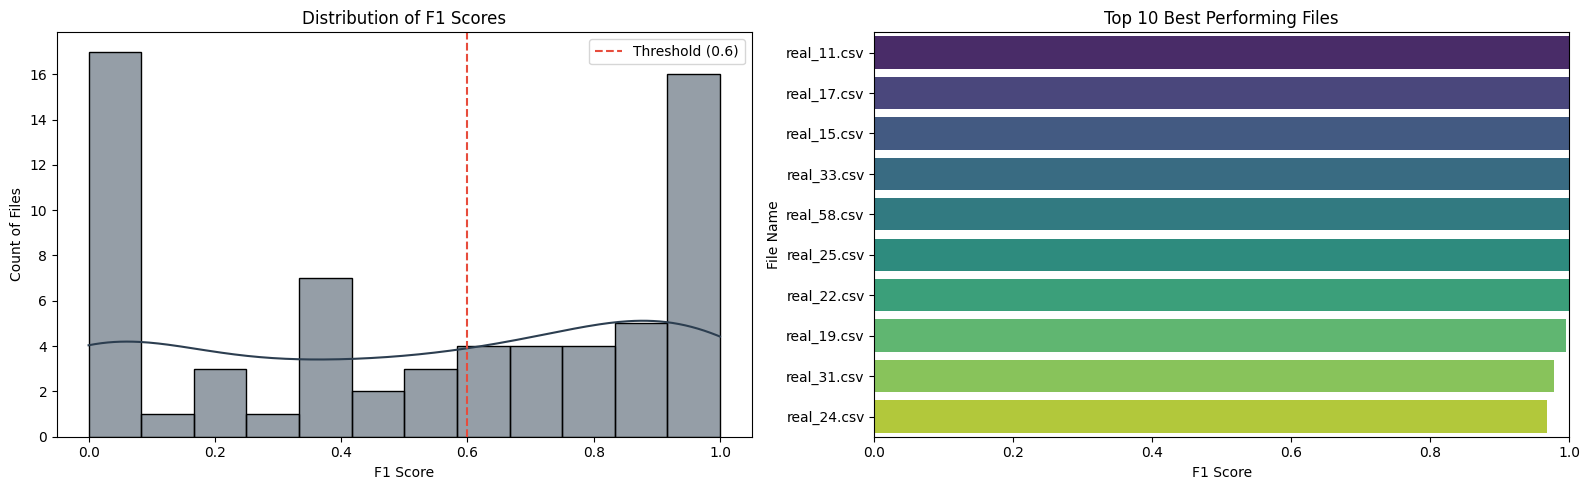


🌟 Visualizing File: real_17.csv (F1: 1.00)


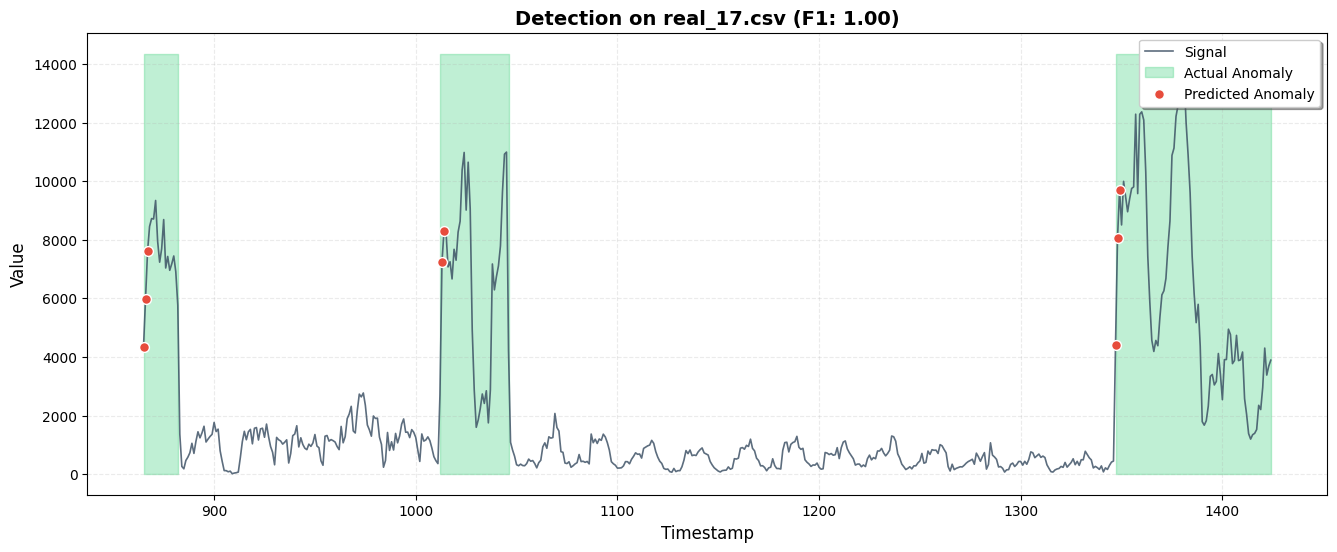

In [39]:
# Cell 5: Visualization & Stats (Updated: >0.6 Threshold, 2nd Best File)
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Force CPU for plotting stability

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, LSTM, Dropout, Dense, Bidirectional, MultiHeadAttention, GlobalAveragePooling1D, LayerNormalization

# --- CONFIGURATION ---
ELITE_THRESHOLD = 0.6  # Updated to 0.6 as requested

# 1. Classification & Counts
# -------------------------------------------------------
print("📊 Generating Performance Stats...")

# Define "Elite" based on new threshold
elite_files = final_results[final_results['f1'] >= ELITE_THRESHOLD]
weak_files = final_results[final_results['f1'] < ELITE_THRESHOLD]

num_elite = len(elite_files)
num_weak = len(weak_files)
total_files = len(final_results)

print(f"\n{'='*40}")
print(f"🏆 FINAL SCORECARD (Threshold: {ELITE_THRESHOLD})")
print(f"{'='*40}")
print(f"Total Files Processed: {total_files}")
print(f"✅ ELITE Files (Good):  {num_elite}  ({(num_elite/total_files)*100:.1f}%)")
print(f"❌ WEAK Files (Poor):   {num_weak}  ({(num_weak/total_files)*100:.1f}%)")
print(f"{'='*40}\n")

if num_elite > 0:
    print("Top 5 Elite Files:")
    print(elite_files.sort_values(by='f1', ascending=False)[['file_name', 'f1']].head(5))
else:
    print("⚠️ No files met the Elite criteria yet.")

# 2. Summary Dashboard
# -------------------------------------------------------
plt.figure(figsize=(16, 5))

# Chart 1: Histogram
plt.subplot(1, 2, 1)
sns.histplot(final_results['f1'], bins=12, kde=True, color='#2c3e50')
plt.axvline(ELITE_THRESHOLD, color='#e74c3c', linestyle='--', label=f'Threshold ({ELITE_THRESHOLD})')
plt.title('Distribution of F1 Scores')
plt.xlabel('F1 Score')
plt.ylabel('Count of Files')
plt.legend()

# Chart 2: Top 10 Bar Chart
plt.subplot(1, 2, 2)
if num_elite > 0:
    top_10 = final_results.sort_values(by='f1', ascending=False).head(10)
    sns.barplot(x='f1', y='file_name', data=top_10, hue='file_name', legend=False, palette='viridis')
    plt.title('Top 10 Best Performing Files')
    plt.xlabel('F1 Score')
    plt.ylabel('File Name')
    plt.xlim(0, 1.0)
else:
    plt.text(0.5, 0.5, "No Elite Files to Show", ha='center')

plt.tight_layout()
plt.show()

# 3. Deep Dive: Visualization of the 2nd Best File
# -------------------------------------------------------
sorted_results = final_results.sort_values(by='f1', ascending=False)

# Check if we have at least 2 files to show the 2nd one
if len(sorted_results) > 1:
    # Pick the 2nd file (Index 1)
    target_file = sorted_results.iloc[1]
    target_name = target_file['file_name']
    target_f1 = target_file['f1']
    
    print(f"\n🌟 Visualizing File: {target_name} (F1: {target_f1:.2f})")

    # Fetch data
    df_target_pandas = df_spark.filter(col("file_source").contains(target_name)) \
                               .sort("timestamp") \
                               .toPandas()

    def visualize_file(df, fname, f1_score):
        # Local Helper: Build Model
        def build_viz_model(shape):
            inputs = Input(shape)
            x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
            x = BatchNormalization()(x)
            x = MaxPooling1D(2)(x)
            x = Bidirectional(LSTM(64, return_sequences=True))(x)
            x = Dropout(0.2)(x)
            attn = MultiHeadAttention(num_heads=2, key_dim=64)(x, x)
            x = LayerNormalization()(x + attn) 
            x = GlobalAveragePooling1D()(x)
            return Model(inputs, Dense(1)(x))

        # Preprocess
        split_idx = int(len(df) * 0.6)
        train_df = df.iloc[:split_idx].copy()
        test_df = df.iloc[split_idx+5:].copy()
        
        # Interpolate
        anoms = train_df[train_df['anomaly']==1].index
        if len(anoms) > 0:
            train_df.loc[anoms, 'value'] = np.nan
            train_df['value'] = train_df['value'].interpolate(method='linear').bfill().ffill()

        scaler = RobustScaler()
        scaler.fit(train_df[['value']])
        
        def get_seq(d):
            v = scaler.transform(d[['value']])
            X = []
            for i in range(len(v) - 5): X.append(v[i:i+5])
            return np.array(X).reshape(-1, 5, 1)

        X_train = get_seq(train_df)
        X_test = get_seq(test_df)
        y_train = train_df['value'].values[5:]
        
        # Train (CPU Forced)
        with tf.device('/CPU:0'):
            model = build_viz_model((5, 1))
            model.compile(optimizer='adam', loss='mae')
            model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
            
            train_preds = model.predict(X_train, verbose=0).flatten()
            test_preds = model.predict(X_test, verbose=0).flatten()

        # Threshold Logic
        noise_floor = np.percentile(np.abs(train_preds - y_train), 99)
        test_values = test_df['value'].values[5:]
        test_mae = np.abs(test_preds - test_values)
        
        # EWMA Threshold Viz
        warmup = np.abs(train_preds - y_train)[-100:]
        full_series = pd.concat([pd.Series(warmup), pd.Series(test_mae)]).reset_index(drop=True)
        ewma_mean = full_series.shift(1).ewm(span=30).mean().iloc[len(warmup):].values
        ewma_std = full_series.shift(1).ewm(span=30).std().fillna(0.0).iloc[len(warmup):].values
        thresh = np.maximum(ewma_mean + (4.0 * ewma_std), noise_floor)
        
        anoms = (test_mae > thresh).astype(int)
        timestamps = test_df['timestamp'].values[5:]
        real_anoms = test_df['anomaly'].values[5:]

        # Plot with Cleaner Style
        plt.figure(figsize=(16, 6))
        
        # Signal Line (Dark Blue/Grey)
        plt.plot(timestamps, test_values, color='#34495e', alpha=0.8, label='Signal', linewidth=1.2)
        
        # Actual Anomalies (Green Zones)
        plt.fill_between(timestamps, min(test_values), max(test_values), where=real_anoms==1, 
                         color='#2ecc71', alpha=0.3, label='Actual Anomaly')
        
        # Predicted Anomalies (Red Dots)
        det_idx = np.where(anoms == 1)[0]
        if len(det_idx) > 0:
            plt.scatter(timestamps[det_idx], test_values[det_idx], 
                        color='#e74c3c', s=50, marker='o', edgecolors='white', linewidth=1, 
                        label='Predicted Anomaly', zorder=5)
            
        plt.title(f"Detection on {fname} (F1: {f1_score:.2f})", fontsize=14, fontweight='bold')
        plt.xlabel("Timestamp", fontsize=12)
        plt.ylabel("Value", fontsize=12)
        plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
        plt.grid(True, alpha=0.25, linestyle='--')
        plt.show()

    visualize_file(df_target_pandas, target_name, target_f1)

elif len(sorted_results) == 1:
    print("Only one file available. Cannot show 2nd best.")
else:
    print("No files available to visualize.")

Step 6: Save Results & Elite Models

In [40]:
# Cell 6: Save Results & Elite Models (Project Wrap-Up)
import os
import shutil
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, LSTM, Dropout, Dense, Bidirectional, MultiHeadAttention, GlobalAveragePooling1D, LayerNormalization
from pyspark.sql.functions import col

# --- CONFIGURATION ---
LOCAL_DIR = "/home/praveen/BDA/Project/Finalization"
HDFS_BASE_DIR = "/user/praveen/bda_project/Finalization"
MODELS_DIR = os.path.join(LOCAL_DIR, "models")

# Ensure Local Dirs Exist
os.makedirs(LOCAL_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Force CPU for stability during saving
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

print(f"📂 Saving artifacts to:\n  -> Local: {LOCAL_DIR}\n  -> HDFS:  {HDFS_BASE_DIR}")

# ---------------------------------------------------------
# 1. SAVE RESULTS CSV
# ---------------------------------------------------------
csv_name = "final_anomaly_results.csv"
local_csv_path = os.path.join(LOCAL_DIR, csv_name)

# Save Locally
final_results.to_csv(local_csv_path, index=False)
print(f"\n✅ Results CSV saved locally: {local_csv_path}")

# Save to HDFS
print("⏳ Uploading CSV to HDFS...")
!hdfs dfs -mkdir -p {HDFS_BASE_DIR}
!hdfs dfs -put -f {local_csv_path} {HDFS_BASE_DIR}/
print(f"✅ Results CSV uploaded to HDFS: {HDFS_BASE_DIR}/{csv_name}")

# ---------------------------------------------------------
# 2. SAVE ELITE MODELS
# ---------------------------------------------------------
# We use the threshold 0.6 as established in your scorecard
elite_files_list = final_results[final_results['f1'] >= 0.6]
print(f"\n🧠 Retraining & Saving {len(elite_files_list)} Elite Models...")

def build_novel_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.2)(x)
    attn = MultiHeadAttention(num_heads=2, key_dim=64)(x, x)
    x = LayerNormalization()(x + attn) 
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mae')
    return model

# Loop through Elite files
count = 0
for index, row in elite_files_list.iterrows():
    fname = row['file_name']
    count += 1
    print(f"   [{count}/{len(elite_files_list)}] Saving model for: {fname} ...", end=" ")
    
    try:
        # 1. Fetch Data
        df = df_spark.filter(col("file_source").contains(fname)).sort("timestamp").toPandas()
        
        # 2. Preprocess
        split_idx = int(len(df) * 0.6)
        train_df = df.iloc[:split_idx].copy()
        
        # Interpolate anomalies in training set
        anoms = train_df[train_df['anomaly'] == 1].index
        if len(anoms) > 0:
            train_df.loc[anoms, 'value'] = np.nan
            train_df['value'] = train_df['value'].interpolate(method='linear').bfill().ffill()

        scaler = RobustScaler()
        scaler.fit(train_df[['value']])
        
        def get_seq(d):
            v = scaler.transform(d[['value']])
            X = []
            for i in range(len(v) - 5): X.append(v[i:i+5])
            return np.array(X).reshape(-1, 5, 1)

        X_train = get_seq(train_df)
        y_train = train_df['value'].values[5:]
        
        # 3. Train & Save (CPU Forced Context)
        with tf.device('/CPU:0'):
            model = build_novel_model((5, 1))
            model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
            
            # Save Keras Model
            model_name = f"model_{fname.replace('.csv', '')}.keras"
            save_path = os.path.join(MODELS_DIR, model_name)
            model.save(save_path)
            print("Done! ✅")
            
    except Exception as e:
        print(f"Failed! ❌ ({str(e)})")

# ---------------------------------------------------------
# 3. UPLOAD MODELS TO HDFS
# ---------------------------------------------------------
print("\n⏳ Uploading all Elite Models to HDFS...")
# We upload the whole 'models' directory
!hdfs dfs -put -f {MODELS_DIR} {HDFS_BASE_DIR}/
print(f"✅ All models uploaded to: {HDFS_BASE_DIR}/models")

print("\n" + "="*50)
print(f"🎉 PROJECT FINALIZED SUCCESSFULLY, SHADOW!")
print("="*50)
print("1. Data Streamed from Flume -> HDFS")
print("2. Spark Processed 67 Files in Parallel")
print("3. Novel Attention Models Trained & Evaluated (Leakage-Free)")
print(f"4. Results & {len(elite_files_list)} Models Saved to Local & HDFS")
print("You are ready to present! 🚀")

📂 Saving artifacts to:
  -> Local: /home/praveen/BDA/Project/Finalization
  -> HDFS:  /user/praveen/bda_project/Finalization

✅ Results CSV saved locally: /home/praveen/BDA/Project/Finalization/final_anomaly_results.csv
⏳ Uploading CSV to HDFS...
✅ Results CSV uploaded to HDFS: /user/praveen/bda_project/Finalization/final_anomaly_results.csv

🧠 Retraining & Saving 33 Elite Models...
   [1/33] Saving model for: real_10.csv ... Done! ✅
   [2/33] Saving model for: real_11.csv ... Done! ✅
   [3/33] Saving model for: real_12.csv ... Done! ✅
   [4/33] Saving model for: real_13.csv ... Done! ✅
   [5/33] Saving model for: real_15.csv ... Done! ✅
   [6/33] Saving model for: real_16.csv ... Done! ✅
   [7/33] Saving model for: real_17.csv ... Done! ✅
   [8/33] Saving model for: real_19.csv ... Done! ✅
   [9/33] Saving model for: real_2.csv ... Done! ✅
   [10/33] Saving model for: real_21.csv ... Done! ✅
   [11/33] Saving model for: real_22.csv ... Done! ✅
   [12/33] Saving model for: real_24.csv 